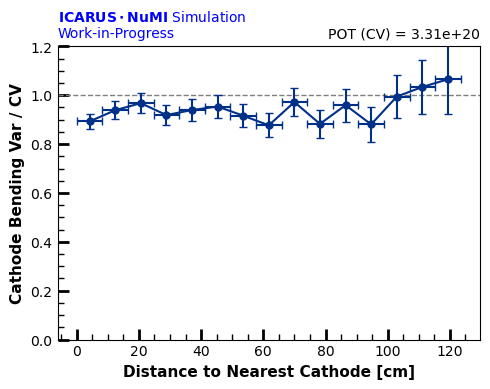

Saved: cathode_bending_proximity_contained


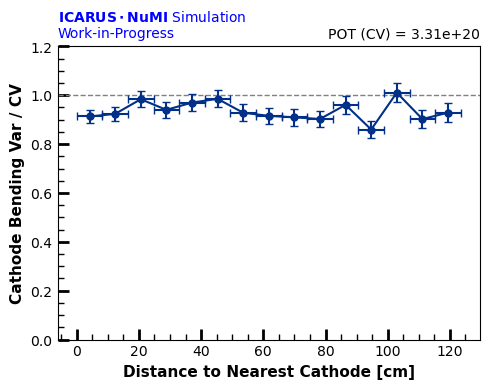

Saved: cathode_bending_proximity_exiting


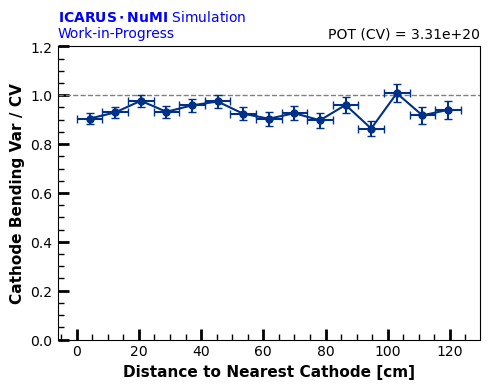

Saved: cathode_bending_proximity_combined


In [4]:
# Cathode Bending Var/CV vs. distance to nearest cathode plane.
# Answers reviewer comment #17 (Anne, Fig. 31): whether the Cathode Bending
# detector systematic has a larger impact on events in proximity to or
# crossing the cathode.
#
# Produces THREE SEPARATE single-panel figures (contained, exiting,
# combined) rather than one composite multi-panel plot -- this matches the
# existing convention in dpT.toml, where dpT_detSysUncertainty_contained/
# _exiting/_combined are each their own [[figure]] block (figsize=[5,4]),
# later assembled in the .tex file with \subcaption{} for the (a)/(b)/(c)
# lettering. The (a)/(b)/(c) labels therefore do NOT get drawn inside the
# image here -- that's the LaTeX file's job, same as the rest of the
# systematics section.
#
# Cathode planes located empirically at x = +-210 cm from the vertex-x gap
# structure (see cathode_proximity_final.py exploration). Distance uses
# whichever of vertex or track-endpoint x is closer to a cathode, so tracks
# that cross the cathode without starting near it still register as close.
# CV/var09 samples POT-normalized (NORM_VAR09 = POT_cv / POT_var09) since
# they are independent MC productions.

import os
import uproot
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = os.getcwd()

MEDULLA_INPUT = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/"
    "ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"
)

CATHODE_X_POSITIONS = [-210.0, 210.0]
VTX_X, END_X = "reco_vertex_x", "reco_leading_muon_end_x"
CONTAINMENT = "reco_leading_muon_containment"

f = uproot.open(MEDULLA_INPUT)
cv_tree = f["events/cv/selected"]
var09_tree = f["events/var09/selected"]

pot_cv = f["events/cv/POT"].to_numpy()[0].sum()
pot_var09 = f["events/var09/POT"].to_numpy()[0].sum()
NORM_CV, NORM_VAR09 = 1.0, pot_cv / pot_var09

cv_arrs = cv_tree.arrays([VTX_X, END_X, CONTAINMENT], library="np")
var_arrs = var09_tree.arrays([VTX_X, END_X, CONTAINMENT], library="np")


def distance_to_cathode(vtx_x, end_x, cathodes):
    vtx_x, end_x, cathodes = np.asarray(vtx_x), np.asarray(end_x), np.asarray(cathodes)
    d_vtx = np.min(np.abs(vtx_x[:, None] - cathodes[None, :]), axis=1)
    d_end = np.min(np.abs(end_x[:, None] - cathodes[None, :]), axis=1)
    return np.minimum(d_vtx, d_end)


cv_dist = distance_to_cathode(cv_arrs[VTX_X], cv_arrs[END_X], CATHODE_X_POSITIONS)
var_dist = distance_to_cathode(var_arrs[VTX_X], var_arrs[END_X], CATHODE_X_POSITIONS)

N_DIST_BINS = 15  # finer binning than the original 7 bins
DIST_BINS = np.linspace(0, max(cv_dist.max(), var_dist.max()), N_DIST_BINS + 1)
CENTERS = 0.5 * (DIST_BINS[:-1] + DIST_BINS[1:])
HALF_WIDTHS = 0.5 * (DIST_BINS[1:] - DIST_BINS[:-1])  # horizontal error bars = bin half-width

# None = no containment mask -> all events (the combined sample)
CATEGORIES = [
    ("contained", True),
    ("exiting", False),
    ("combined", None),
]

for sub in ("pdf", "jpeg"):
    os.makedirs(os.path.join(OUT_DIR, sub), exist_ok=True)

for name, is_contained in CATEGORIES:
    if is_contained is None:
        cv_mask = np.ones(len(cv_arrs[CONTAINMENT]), dtype=bool)
        var_mask = np.ones(len(var_arrs[CONTAINMENT]), dtype=bool)
    else:
        cv_mask = cv_arrs[CONTAINMENT].astype(bool) == is_contained
        var_mask = var_arrs[CONTAINMENT].astype(bool) == is_contained

    cv_y, _ = np.histogram(cv_dist[cv_mask], bins=DIST_BINS)
    var_y, _ = np.histogram(var_dist[var_mask], bins=DIST_BINS)

    ratio = np.divide(
        var_y * NORM_VAR09, cv_y * NORM_CV,
        out=np.full_like(var_y, np.nan, dtype=float), where=(cv_y * NORM_CV) > 0,
    )
    rel_err = np.sqrt(
        np.divide(1.0, var_y, out=np.full_like(var_y, np.nan, dtype=float), where=var_y > 0)
        + np.divide(1.0, cv_y, out=np.full_like(cv_y, np.nan, dtype=float), where=cv_y > 0)
    )
    ratio_err = ratio * rel_err

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax.errorbar(CENTERS, ratio, yerr=ratio_err, xerr=HALF_WIDTHS, marker="o", color="#003087",
                linestyle="-", linewidth=1.5, markersize=5, capsize=3,
                label="Cathode Bending / CV")

    # Explicit y-range from the actual data extent (ratio +/- its error, and
    # the y=1 reference line) with a fixed 10% pad. Without this,
    # matplotlib's default autoscale was snapping to round-number ticks
    # (0.0-1.2) regardless of the much narrower true data range, wasting
    # most of the plot on blank space.
    valid = np.isfinite(ratio) & np.isfinite(ratio_err)
    lower = min(np.min(ratio[valid] - ratio_err[valid]), 1.0)
    upper = max(np.max(ratio[valid] + ratio_err[valid]), 1.0)
    pad = 0.1 * (upper - lower)
    ax.set_ylim(lower - pad, upper + pad)

    ax.set_xlabel("Distance to Nearest Cathode [cm]", fontsize=11, fontweight="bold",
                   fontfamily="sans-serif")
    ax.set_ylabel("Cathode Bending Var / CV", fontsize=11, fontweight="bold",
                   fontfamily="sans-serif")
    ax.tick_params(axis="both", which="major", labelsize=10, size=8, width=2, direction="in")
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", size=4, width=1, direction="in")
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily("sans-serif")

    # Fixed to axes-fraction coordinates (transAxes) rather than data
    # coordinates -- anchoring to ax.get_ylim()[1] let autoscale pad the
    # figure inconsistently across panels (large blank band above the
    # frame), and the legend location collided with the y=1 reference line
    # / data points in the exiting and combined panels. A legend is also
    # redundant here (single series, already named by the y-axis label), so
    # it's dropped rather than relocated.
    ax.text(0.0, 1.02, r"$\bf{ICARUS \cdot NuMI}$ Simulation" + "\n" + "Work-in-Progress",
            transform=ax.transAxes, fontsize=10, color="blue",
            verticalalignment="bottom", horizontalalignment="left",
            fontfamily="sans-serif", clip_on=False)
    ax.text(1.0, 1.02, f"POT (CV) = {pot_cv:.2e}",
            transform=ax.transAxes, fontsize=10, color="black",
            verticalalignment="bottom", horizontalalignment="right",
            fontfamily="sans-serif", clip_on=False)
    ax.set_ylim(0, 1.2)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"pdf/cathode_bending_proximity_{name}.pdf"),
                bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUT_DIR, f"jpeg/cathode_bending_proximity_{name}.jpeg"),
                bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Saved: cathode_bending_proximity_{name}")


events/cv/selected             -> FOUND, 44728 entries
events/var04p/selected         -> FOUND, 28806 entries
events/var04m/selected         -> FOUND, 29351 entries
  reco_dpT_lp                         FOUND
  reco_leading_muon_ke                FOUND
  reco_leading_muon_containment       FOUND
POT_cv=3.312e+20  POT_var04p=2.138e+20 (norm=1.549)  POT_var04m=2.159e+20 (norm=1.534)
        dpT bin    N_cv   frac(+1sig)   frac(-1sig)
      30.0 MeV/c    1995   0.007+/-0.000    0.015+/-0.001
      90.0 MeV/c    4911   0.019+/-0.000    0.019+/-0.000
     150.0 MeV/c    5960   0.012+/-0.000    0.027+/-0.001
     210.0 MeV/c    5668   0.042+/-0.001    0.026+/-0.001
     270.0 MeV/c    4736   0.027+/-0.001    0.023+/-0.001
     330.0 MeV/c    3877   0.030+/-0.001    0.019+/-0.000
     390.0 MeV/c    3335   0.041+/-0.001    0.031+/-0.001
     450.0 MeV/c    2702   0.020+/-0.001    0.017+/-0.001
     510.0 MeV/c    2314   0.017+/-0.001    0.051+/-0.002
     570.0 MeV/c    1810   0.045+/-0.002  

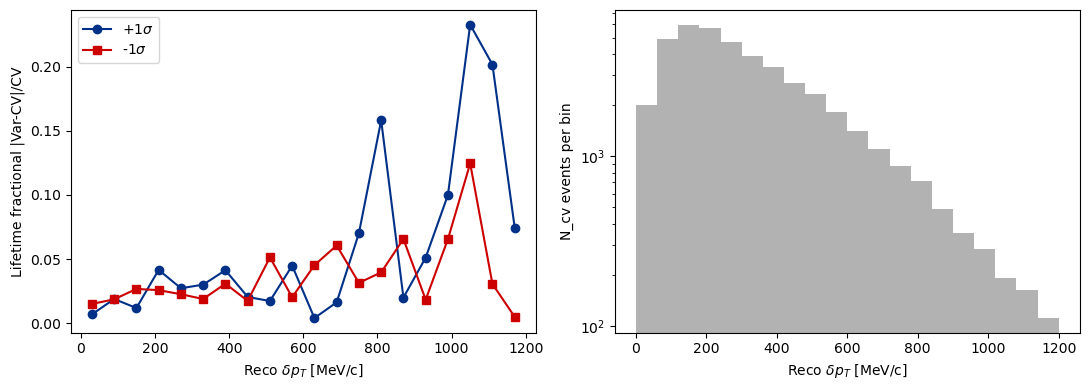

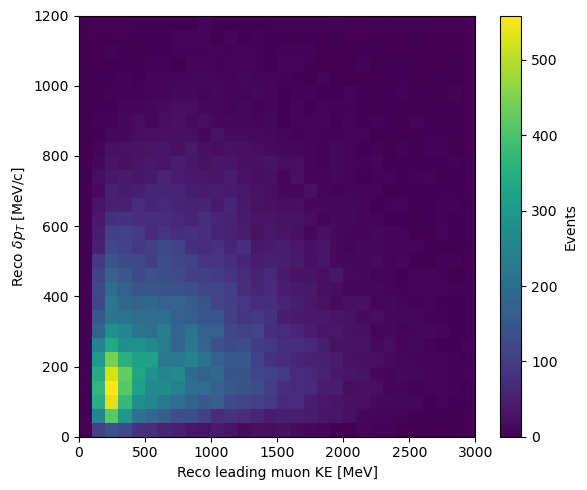

In [1]:
# %% [markdown]
# # Lifetime fractional uncertainty vs. delta_pT -- reviewer comments #18 (Anne)
# # and 4.3 (London), investigated together
#
# Anne (Fig 32): "do you understand why the lifetime fractional uncertainty
# increases with higher delta_p_T?"
#
# London (4.3): "The electron lifetime variation looks to have a larger
# impact on muon KE than the cathode bending variation, particularly at low
# energy. I would expect that low muon KE would translate to on average
# lower delta_pT as well. Can we explain how this is compatible with fig 32
# where lifetime variation is so sub-dominant at all delta_pT except the
# highest?"
#
# Both comments are about the same underlying curve: the Lifetime line in
# the detector-systematics-vs-delta_pT breakdown (fig:det_frac_unc /
# dpT_detSysUncertainty), which per Systematics.tex reports a small
# bin-averaged Lifetime uncertainty (~2.5%) but apparently rises toward the
# highest delta_pT bin specifically.
#
# Lifetime is var04 (two-sided: var04p, var04m) per dpT.toml's
# systematic_recipe. Per Systematics.tex: nominal MC assumes 3 ms lifetime,
# Run 2 data measured ~4 ms (East) / ~8 ms (West) -- i.e. the simulation
# UNDER-estimates the real lifetime, so real charge attenuation should be
# LESS than simulated.
#
# This script checks two candidate explanations empirically, without
# assuming either is right:
#   (a) statistics artifact: the highest delta_pT bin(s) have few CV events,
#       so the same absolute Var-CV difference produces a much larger
#       fractional swing there than in well-populated bins (this is exactly
#       what turned out to be the case for the sparse tail bin in the
#       Cathode Bending proximity check).
#   (b) genuine physics trend: the Lifetime variation's impact on reco_dpT
#       itself grows with delta_pT (e.g. because events at high delta_pT
#       disproportionately involve exiting muons/protons with long drift
#       paths, where lifetime mismodeling has more effect).
#
# Uses the same medulla input file and cv/var04p/var04m per-event trees
# as the Cathode Bending investigation.

# %%
import uproot
import numpy as np
import matplotlib.pyplot as plt

MEDULLA_INPUT = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/"
    "ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"
)

f = uproot.open(MEDULLA_INPUT)

# %% [markdown]
# ## Part 1 -- confirm var04p/var04m exist with the branches we need
# Don't assume the branch list matches var09's -- check directly first.

# %%
for grp in ["cv", "var04p", "var04m"]:
    key = f"events/{grp}/selected"
    try:
        t = f[key]
        print(f"{key:30s} -> FOUND, {t.num_entries} entries")
    except Exception as e:
        print(f"{key:30s} -> NOT FOUND ({e})")

NEEDED = ["reco_dpT_lp", "reco_leading_muon_ke", "reco_leading_muon_containment"]
cv_branches = f["events/cv/selected"].keys()
for b in NEEDED:
    print(f"  {b:35s} {'FOUND' if b in cv_branches else 'MISSING'}")

# %% [markdown]
# ## Part 2 -- load CV and both Lifetime variation samples
# Using reco_dpT_lp (the branch behind the "reco_dpT" plotting variable,
# per variables_uncontained.toml: range [0,1200] MeV/c, 20 bins of 60 MeV/c
# each) and POT-normalizing var04p/var04m onto the CV sample the same way
# as the Cathode Bending check.

# %%
pot_cv = f["events/cv/POT"].to_numpy()[0].sum()
pot_var04p = f["events/var04p/POT"].to_numpy()[0].sum()
pot_var04m = f["events/var04m/POT"].to_numpy()[0].sum()

BR = ["reco_dpT_lp", "reco_leading_muon_ke", "reco_leading_muon_containment"]
cv = f["events/cv/selected"].arrays(BR, library="np")
p = f["events/var04p/selected"].arrays(BR, library="np")
m = f["events/var04m/selected"].arrays(BR, library="np")

norm_p = pot_cv / pot_var04p
norm_m = pot_cv / pot_var04m
print(f"POT_cv={pot_cv:.3e}  POT_var04p={pot_var04p:.3e} (norm={norm_p:.3f})  "
      f"POT_var04m={pot_var04m:.3e} (norm={norm_m:.3f})")

# %% [markdown]
# ## Part 3 -- bin by reco_dpT_lp, same edges as the technote's reco_dpT
# variable (matches variables_uncontained.toml exactly).

# %%
DPT_BINS = np.linspace(0, 1200, 21)  # 20 bins of 60 MeV/c
CENTERS = 0.5 * (DPT_BINS[:-1] + DPT_BINS[1:])

cv_y, _ = np.histogram(cv["reco_dpT_lp"], bins=DPT_BINS)
p_y, _ = np.histogram(p["reco_dpT_lp"], bins=DPT_BINS)
m_y, _ = np.histogram(m["reco_dpT_lp"], bins=DPT_BINS)

def frac_diff(var_y, norm, cv_y):
    """|Var*norm - CV| / CV per bin, with Poisson error on the fractional
    difference from both samples' counting statistics."""
    scaled = var_y * norm
    diff = np.divide(np.abs(scaled - cv_y), cv_y,
                      out=np.full_like(cv_y, np.nan, dtype=float), where=cv_y > 0)
    rel_err = np.sqrt(
        np.divide(1.0, var_y, out=np.full_like(var_y, np.nan, dtype=float), where=var_y > 0)
        + np.divide(1.0, cv_y, out=np.full_like(cv_y, np.nan, dtype=float), where=cv_y > 0)
    )
    return diff, diff * rel_err

frac_p, err_p = frac_diff(p_y, norm_p, cv_y)
frac_m, err_m = frac_diff(m_y, norm_m, cv_y)

print(f"{'dpT bin':>15s}  {'N_cv':>6s}  {'frac(+1sig)':>12s}  {'frac(-1sig)':>12s}")
for c, ncv, fp, fm in zip(CENTERS, cv_y, frac_p, frac_m):
    print(f"  {c:8.1f} MeV/c  {ncv:6d}  {fp:6.3f}+/-{err_p[list(CENTERS).index(c)]:.3f}   "
          f"{fm:6.3f}+/-{err_m[list(CENTERS).index(c)]:.3f}")

# %% [markdown]
# ## Part 4 -- plot fractional difference AND raw CV statistics side by side
# If the rise in fractional uncertainty at high delta_pT tracks the fall in
# N_cv (i.e. the two curves mirror each other), that's the statistics-
# artifact explanation. If the fractional difference rises while N_cv is
# still reasonably populated, that points to a genuine physics trend
# instead.

# %%
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(CENTERS, frac_p, marker="o", color="#003087", label="+1$\\sigma$")
axes[0].plot(CENTERS, frac_m, marker="s", color="#CC0000", label="-1$\\sigma$")
axes[0].set_xlabel("Reco $\\delta p_T$ [MeV/c]")
axes[0].set_ylabel("Lifetime fractional |Var-CV|/CV")
axes[0].legend()

axes[1].bar(CENTERS, cv_y, width=np.diff(DPT_BINS), color="gray", alpha=0.6)
axes[1].set_xlabel("Reco $\\delta p_T$ [MeV/c]")
axes[1].set_ylabel("N_cv events per bin")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

# %% [markdown]
# ## Part 5 -- check London's angle: Lifetime's impact on muon KE vs. dpT
# London's point is that Lifetime has a bigger effect on LOW muon KE than
# Cathode Bending does, but ends up sub-dominant except at the HIGHEST
# delta_pT bin. That's only a contradiction if low muon KE maps cleanly
# onto low delta_pT. Check that mapping directly instead of assuming it:
# 2D histogram of reco_leading_muon_ke vs reco_dpT_lp for the CV sample.

# %%
fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(cv["reco_leading_muon_ke"], cv["reco_dpT_lp"],
              bins=[30, 30], range=[[0, 3000], [0, 1200]], cmap="viridis")
ax.set_xlabel("Reco leading muon KE [MeV]")
ax.set_ylabel("Reco $\\delta p_T$ [MeV/c]")
plt.colorbar(h[3], ax=ax, label="Events")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## What to look for
#
# 1. In Part 4's left panel: does the fractional-difference curve for
#    Lifetime actually rise monotonically toward high delta_pT, or is it
#    noisy/flat until a single sparse tail bin spikes (same pattern as the
#    Cathode Bending proximity check)? Compare directly against the right
#    panel's N_cv falloff.
# 2. In Part 5's 2D histogram: is there a tight correlation between muon KE
#    and delta_pT, or is delta_pT spread across a wide range of muon KE at
#    fixed KE (and vice versa)? If the correlation is loose, London's
#    "low KE -> low delta_pT" assumption may simply not hold in this
#    sample, which would resolve the apparent tension without needing any
#    other explanation.